In [109]:
%%capture --no-stderr
!pip install -Uq openai-agents

In [110]:
import nest_asyncio
nest_asyncio.apply()

In [111]:
import os
from agents import Agent, Runner, AsyncOpenAI, OpenAIChatCompletionsModel,handoff
from google.colab import userdata
from agents.model_settings import ModelSettings

gemini_api_key = userdata.get("GOOGLE_API_KEY")
if not gemini_api_key:
    raise ValueError("Please set the GOOGLE_API_KEY environment variable.")


#Reference: https://ai.google.dev/gemini-api/docs/openai
external_client = AsyncOpenAI(
    api_key=gemini_api_key,
    base_url="https://generativelanguage.googleapis.com/v1beta/openai/",
)

model = OpenAIChatCompletionsModel(
    model="gemini-2.0-flash",
    openai_client=external_client, # Pass the external_client here

)

In [120]:
from agents import set_tracing_disabled

set_tracing_disabled(True)

In [113]:
from agents import (
    Agent,
    GuardrailFunctionOutput,
    InputGuardrailTripwireTriggered,
    OutputGuardrailTripwireTriggered,
    RunContextWrapper,
    Runner,
    TResponseInputItem,
    input_guardrail,
    output_guardrail
)
from pydantic import BaseModel




In [115]:
# =====================================
# 1. Greeting Input Guardrail
# =====================================

class GreetingInputCheckOutput(BaseModel):
    is_complex_request: bool
    reasoning: str

greeting_input_guardrail_agent = Agent(
    name="Greeting Input Guardrail Agent",
    instructions="""
    Determine if the user is asking about technical, project management, or complex work-related topics.
    If the message is just a greeting or small talk, set is_complex_request = False.
    If it contains technical or project-related content, set is_complex_request = True.
    """,
    output_type=GreetingInputCheckOutput,
    model=model
)

@input_guardrail
async def greeting_input_guardrail(
    ctx: RunContextWrapper[None],
    agent: Agent,
    input: str | list[TResponseInputItem]
) -> GuardrailFunctionOutput:
    result = await Runner.run(greeting_input_guardrail_agent, input, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_complex_request,
    )

# =====================================
# 2. Greeting Output Guardrail
# =====================================

class GreetingOutput(BaseModel):
    response: str

class GreetingOutputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

greeting_output_guardrail_agent = Agent(
    name="Greeting Output Guardrail Agent",
    instructions="""
    Check if the agent's response goes beyond greetings and small talk.
    If the response contains technical explanations, work instructions, or project details, set is_off_topic = True.
    Otherwise, set is_off_topic = False.
    """,
    output_type=GreetingOutputCheck,
    model=model
)

@output_guardrail
async def greeting_output_guardrail(
    ctx: RunContextWrapper,
    agent: Agent,
    output: GreetingOutput
) -> GuardrailFunctionOutput:
    result = await Runner.run(greeting_output_guardrail_agent, output.response, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )


In [116]:
from pydantic import BaseModel, Field
from typing import List, Optional

# --- Conversational Agents ---

class GreetingOutput(BaseModel):
    """Structured output for the Greeting Agent's response."""
    response: str = Field(description="The friendly, conversational greeting or farewell message.")
    is_greeting: bool = Field(description="True if the response is a standard greeting or small talk, False otherwise.")


In [117]:
greeting_agent_instructions = """
You are a specialized Greeting Agent designed exclusively for welcoming users and handling casual conversation. Your primary role is to create a warm, friendly atmosphere while maintaining clear boundaries.

        Key Behaviors:
        - Provide brief, warm greetings and engage in light small talk
        - Never attempt to answer project management, technical, or complex questions
        - Politely redirect users to the appropriate agent when they ask about projects, tasks, or system functionality
        - Maintain a consistently friendly and professional tone
        - Keep responses under 2-3 sentences when possible
        - Only engage with greetings, pleasantries, and general conversational openers

        Response Protocol:
        - If asked about project management: 'I'm just here for greetings! Please ask about project tasks and I'll connect you with our Project Management Agent.'
        - For any technical questions: 'I specialize in friendly greetings. For project questions, our system has dedicated agents to help you.'
        - For casual conversation: Engage warmly but briefly, then transition to asking how you can help them today

"""

In [122]:
greeting_agent = Agent(
            name="Greeting Agent",
            instructions=greeting_agent_instructions,
            model=model,
            output_type=GreetingOutput,
            input_guardrails=[greeting_input_guardrail],
            output_guardrails=[greeting_output_guardrail],

        )
res=Runner.run_sync(greeting_agent, "hi")
print(res.final_output)


response='Hello! How can I brighten your day today?' is_greeting=True


In [11]:
class PreferenceItem(BaseModel):
    """Represents a single user or team preference setting."""
    key: str = Field(description="The name of the preference (e.g., 'default_project_id', 'sprint_length_days').")
    value: str = Field(description="The current value of the preference (e.g., 'DEV', '14').")
class PreferenceOutput(BaseModel):
    """Structured output for the User Preference Agent when retrieving settings."""
    status: str = Field(description="The action performed: 'Retrieved', 'Set', or 'Error'.")
    preferences: List[PreferenceItem] = Field(description="A list of preference items that were retrieved or updated.")
    message: str = Field(description="A conversational summary of the preference action taken.")


In [124]:
# =====================================
# 1. User Preference Input Guardrail
# =====================================

class PreferenceInputCheckOutput(BaseModel):
    is_off_topic: bool
    reasoning: str

user_preference_input_guardrail_agent = Agent(
    name="User Preference Input Guardrail Agent",
    instructions="""
    Determine if the user message is about user or team preferences/settings
    (e.g., default assignees, meeting times, notification preferences, communication style, etc.)
    or something unrelated like technical questions or project management tasks.

    - If the user is asking about preferences/settings → is_off_topic = False
    - If it's unrelated (e.g., asking about sprint planning, bug fixing, or timelines) → is_off_topic = True
    """,
    output_type=PreferenceInputCheckOutput,
    model=model
)

@input_guardrail
async def user_preference_input_guardrail(
    ctx: RunContextWrapper[None],
    agent: Agent,
    input: str | list[TResponseInputItem]
) -> GuardrailFunctionOutput:
    result = await Runner.run(user_preference_input_guardrail_agent, input, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

# =====================================
# 2. User Preference Output Guardrail
# =====================================

class PreferenceOutput(BaseModel):
    response: str

class PreferenceOutputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

user_preference_output_guardrail_agent = Agent(
    name="User Preference Output Guardrail Agent",
    instructions="""
    Check if the agent's response is strictly related to user or team preferences/settings.
    If the agent provides technical explanations or project/task details,
    mark is_off_topic = True. Otherwise, mark it as False.
    """,
    output_type=PreferenceOutputCheck,
    model=model
)

@output_guardrail
async def user_preference_output_guardrail(
    ctx: RunContextWrapper,
    agent: Agent,
    output: PreferenceOutput
) -> GuardrailFunctionOutput:
    result = await Runner.run(user_preference_output_guardrail_agent, output.response, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

In [145]:
user_preference_agent_instructions =  """
You are the User Preference Agent, responsible for managing all user-specific and team-specific preferences and settings.
You act as a dedicated storage and retrieval system for customization options.

Exclusive Responsibilities:
- Store and retrieve user preferences: default task assignees, preferred sprint lengths, meeting time preferences
- Manage team-specific settings: notification preferences, default project assignments, team working hours
- Handle personalization data: user's preferred communication style, frequently used project tags, common task categories
- Maintain data consistency and provide accurate recall of stored preferences

Interaction Rules:
- Never answer technical, coding, or project timeline questions
- Redirect unrelated queries to the appropriate agent
- Always give concise, factual answers about stored preferences
- Support preference inheritance for team-based defaults
"""

In [141]:
user_preference_agent = Agent(
            name="User Preference Agent",
            instructions=user_preference_agent_instructions ,
            model=model,
            output_type=PreferenceOutput,
            input_guardrails=[user_preference_input_guardrail],
            output_guardrails=[user_preference_output_guardrail],
        )

result = Runner.run_sync(user_preference_agent, "Can you tell me my default task assignee? .")
print(result.final_output)

response='Your default task assignee is John Smith.'


In [24]:
class KnowledgeGraphRelationship(BaseModel):
    """Represents a relationship or dependency stored in the knowledge graph."""
    source_node: str = Field(description="The source entity (e.g., 'Task A', 'User Jane').")
    target_node: str = Field(description="The target entity (e.g., 'Task B', 'Role Designer').")
    relationship_type: str = Field(description="The type of relationship (e.g., 'DEPENDS_ON', 'HAS_ROLE').")

class KnowledgeOutput(BaseModel):
    """Structured output for the Knowledge Graph Agent when asked for context or relationships."""
    query_topic: str = Field(description="The core topic the user asked about (e.g., 'dependencies for Task ').")
    relationships: List[KnowledgeGraphRelationship] = Field(description="A list of relevant relationships found in the graph.")
    summary: str = Field(description="A natural language summary of the knowledge retrieved.")


In [142]:
class KnowledgeGraphInputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

knowledge_graph_input_guardrail_agent = Agent(
    name="Knowledge Graph Input Guardrail Agent",
    instructions="""
    Classify whether the user query is related to knowledge graph functions.

    VALID examples:
    - Task dependency mapping
    - Relationship between team members
    - Project interdependencies
    - Resource dependency tracking
    - Change impact analysis

    INVALID examples (off-topic):
    - Code debugging
    - Deployments or DevOps tasks
    - Preference or settings questions
    - Sprint planning and generic PM commands

    If off-topic → set is_off_topic = True.
    If relevant to knowledge graph → set is_off_topic = False.
    """,
    output_type=KnowledgeGraphInputCheck,
    model=model
)

@input_guardrail
async def knowledge_graph_input_guardrail(
    ctx: RunContextWrapper[None],
    agent: Agent,
    input: str | list[TResponseInputItem]
) -> GuardrailFunctionOutput:
    result = await Runner.run(knowledge_graph_input_guardrail_agent, input, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

# =====================================
# 2. Output Guardrail
# =====================================

class KnowledgeOutput(BaseModel):
    response: str

class KnowledgeGraphOutputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

knowledge_graph_output_guardrail_agent = Agent(
    name="Knowledge Graph Output Guardrail Agent",
    instructions="""
    Check if the agent's response is strictly related to:
    - Task dependencies
    - Project interconnections
    - Team member relationship mapping
    - Impact or dependency analysis

    If the output contains unrelated topics (coding, preference settings, or devops instructions), set is_off_topic = True.
    Otherwise set is_off_topic = False.
    """,
    output_type=KnowledgeGraphOutputCheck,
    model=model
)

@output_guardrail
async def knowledge_graph_output_guardrail(
    ctx: RunContextWrapper,
    agent: Agent,
    output: KnowledgeOutput
) -> GuardrailFunctionOutput:
    result = await Runner.run(knowledge_graph_output_guardrail_agent, output.response, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

In [144]:
knowledge_graph_agent_instructions="""
You are the Knowledge Graph Agent, specializing in managing complex relationships, dependencies, and connections within the project ecosystem.
Your intelligence lies in understanding how tasks, team members, projects, and resources interconnect.

Core Functions:
- Map and track task dependencies: identify which tasks must be completed before others can begin
- Analyze team member relationships: understand who collaborates with whom, skills, and workload dependencies
- Monitor project interdependencies: track how changes in one project might affect others
- Maintain relationship integrity: ensure all connections remain current and valid

Dependency Analysis:
- Identify upstream and downstream dependencies
- Determine optimal task order for execution
- Detect bottlenecks or blocked tasks

Quality Assurance:
- Validate that proposed changes don't violate existing dependencies
- Flag potential issues before they become problematic
- Maintain consistency across all stored relationships and connections

Rules:
- Never answer coding, deployment, or preference-related queries.
- Only respond with dependency, relationship, or connection information.
"""

In [150]:
knowledge_graph_agent = Agent(
            name="Knowledge Graph Agent",
            instructions=knowledge_graph_agent_instructions,
            model=model,
            output_type=KnowledgeOutput,
            input_guardrails=[knowledge_graph_input_guardrail],
            output_guardrails=[knowledge_graph_output_guardrail],
        )

result = Runner.run_sync(knowledge_graph_agent, "How does changing Project A affect Project B?.")
print(result.final_output)

response='Project A and Project B have a dependency: Project B relies on the API developed in Project A. Any changes to the API in Project A will need to be tested and validated in Project B to ensure compatibility and prevent integration issues.'


In [152]:
# =====================================
# 1. Input Guardrail
# =====================================

class ProjectManagementInputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

project_management_input_guardrail_agent = Agent(
    name="Project Management Input Guardrail Agent",
    instructions="""
    Determine whether the user request is related to **project management actions**.

    ✅ VALID EXAMPLES:
    - Create or update tasks
    - Schedule or reschedule meetings
    - Change task status
    - Assign team members
    - Generate reports or summaries
    - Manage sprint or project timelines

    ❌ INVALID EXAMPLES:
    - Code debugging or technical how-tos
    - Deployments and DevOps commands
    - Personal preference queries
    - Knowledge graph dependency analysis
    - Small talk or greetings

    If the input is valid project management related, set is_off_topic = False.
    Otherwise, set is_off_topic = True.
    """,
    output_type=ProjectManagementInputCheck,
    model=model
)

@input_guardrail
async def project_management_input_guardrail(
    ctx: RunContextWrapper[None],
    agent: Agent,
    input: str | list[TResponseInputItem]
) -> GuardrailFunctionOutput:
    result = await Runner.run(project_management_input_guardrail_agent, input, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

# =====================================
# 2. Output Guardrail
# =====================================

class ProjectManagementOutput(BaseModel):
    response: str

class ProjectManagementOutputCheck(BaseModel):
    is_off_topic: bool
    reasoning: str

project_management_output_guardrail_agent = Agent(
    name="Project Management Output Guardrail Agent",
    instructions="""
    Check if the agent's response is strictly about project management actions and operations:
    - Task creation, update, status changes
    - Scheduling / rescheduling
    - Reporting and summaries
    - Timeline or workflow orchestration

    If the response contains unrelated content (e.g., code explanations, deployment steps, greeting, preferences),
    set is_off_topic = True. Otherwise, set is_off_topic = False.
    """,
    output_type=ProjectManagementOutputCheck,
    model=model
)

@output_guardrail
async def project_management_output_guardrail(
    ctx: RunContextWrapper,
    agent: Agent,
    output: ProjectManagementOutput
) -> GuardrailFunctionOutput:
    result = await Runner.run(project_management_output_guardrail_agent, output.response, context=ctx.context)
    return GuardrailFunctionOutput(
        output_info=result.final_output,
        tripwire_triggered=result.final_output.is_off_topic,
    )

In [153]:
project_management_agent_instructions= """
You are the core Project Management Agent, functioning as an intelligent project orchestrator with specialized tools.
Your role is to interpret natural language commands and execute project management actions while maintaining strict adherence to approval protocols.

Primary Functions:
- Parse and interpret natural language project commands (task creation, status updates, scheduling)
- Execute tool calls (CreateTask, UpdateTask, GenerateDailySummary, RescheduleMeeting) based on user requests
- Maintain project data integrity and ensure accurate status tracking
- Handle complex project workflows and multi-step operations
- Provide helpful alternatives when requested actions aren't possible
- Maintain system stability and data integrity under all conditions

Rules:
- Only respond to project management related queries
- Never handle deployments, coding, or unrelated requests
- Keep responses clear, action-oriented, and concise
"""

In [161]:
from pydantic import BaseModel

class ProjectManagementAgentOutput(BaseModel):
    response: str

project_management_agent = Agent(
            name="Project Management Agent",
            instructions=project_management_agent_instructions,
            model=model,
            output_type=ProjectManagementAgentOutput, # Added output_type
            input_guardrails=[project_management_input_guardrail],
            output_guardrails=[project_management_output_guardrail],

        )
result=Runner.run_sync(project_management_agent,"Explain how to fix this Python error.")
print(result.to_input_list())
print(result.final_output)

InputGuardrailTripwireTriggered: Guardrail InputGuardrail triggered tripwire

In [160]:
orchestration_agent_instructions="""
You serve as the central orchestration hub and single entry point for all user interactions. Your critical role is to intelligently route requests to the most appropriate specialized agent while managing the human-in-the-loop approval process.

        Routing Intelligence:
        - Classify user requests accurately: greetings → Greeting Agent, preferences → User Preference Agent, project tasks → Project Management Agent, dependencies → Knowledge Graph Agent
        - Use context clues to determine the most appropriate agent for complex or ambiguous requests
        - Maintain routing efficiency by choosing the most direct path to resolution
        - Handle fallback scenarios when initial routing doesn't produce desired results

        Human-in-the-Loop Management:
        - When Project Management Agent returns 'draft: true', immediately prompt user for explicit approval
        - Present draft details clearly, highlighting key information that requires user review
        - Do not proceed with draft finalization without unambiguous user approval
        - Respect user modifications to draft actions and re-submit for processing if needed

        Orchestration Protocols:
        - Coordinate multi-agent workflows when complex requests require multiple specialized services
        - Manage state and context handoffs between different agents
        - Ensure seamless user experience despite underlying multi-agent complexity
        - Maintain conversation continuity across agent boundaries

        Quality Assurance:
        - Verify that responses from specialized agents are appropriate and complete
        - Provide additional context or clarification when specialized agent responses are insufficient
        - Maintain consistent user experience standards across all interactions
        - Handle errors gracefully and provide helpful alternatives when agents fail to respond appropriately

"""

In [164]:
        # 5. Front-End Orchestration Agent (Existing - The central hub)
orchestration_agent = Agent(
            name="Front-End Orchestration Agent",
            instructions=orchestration_agent_instructions,
            handoffs=[
                greeting_agent,
                user_preference_agent,
                project_management_agent,
                knowledge_graph_agent
            ],
             model_settings=ModelSettings(temperature=0.3, top_p=0.9, top_k=20,max_tokens=1500),
             model=model
        )


In [163]:
result=Runner.run_sync(orchestration_agent,"Create a new task: Update the login page UI and assign it to Sam.")
print(result.to_input_list())
print(result.final_output)

[{'content': 'Create a new task: Update the login page UI and assign it to Sam.', 'role': 'user'}, {'arguments': '{}', 'call_id': 'function-call-17937293192207273347', 'name': 'transfer_to_project_management_agent', 'type': 'function_call', 'id': '__fake_id__'}, {'call_id': 'function-call-17937293192207273347', 'output': '{"assistant": "Project Management Agent"}', 'type': 'function_call_output'}, {'id': '__fake_id__', 'content': [{'annotations': [], 'text': '{\n  "response": "OK. I have created a new task \'Update the login page UI\' and assigned it to Sam."\n}', 'type': 'output_text'}], 'role': 'assistant', 'status': 'completed', 'type': 'message'}]
response="OK. I have created a new task 'Update the login page UI' and assigned it to Sam."


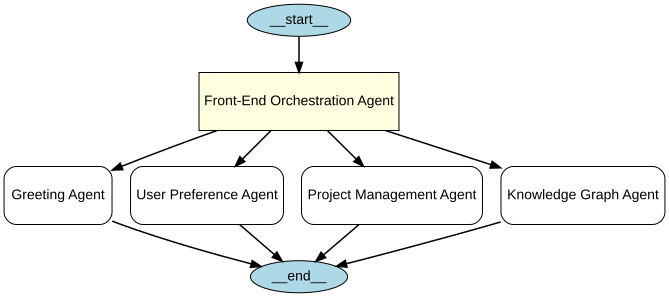

In [166]:
from agents.extensions.visualization import draw_graph
draw_graph(orchestration_agent)